# 03 — Physical plausibility filtering and temperature correction

This notebook applies the first filtering and correction stage to the raw base dataset.

The purpose of this notebook is to:

1. restrict the dataset to the selected 2017–2021 PLR analysis window
2. apply broad physical plausibility filters to irradiance and electrical measurements
3. diagnose and repair the Module 6 backsheet-temperature sensor fault
4. save the repaired row-level dataset for downstream irradiance filtering and performance-ratio calculation

The output of this notebook is `df_plr_repaired.parquet`.

## 1. Imports and plotting style

The plotting style is kept consistent with the exploratory data analysis notebook.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------------------
# Plotting style
# ---------------------------------------------------------------------

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,

    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 12,
    "legend.title_fontsize": 12,

    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.7,
})

TITLE_SIZE = 16
SUBTITLE_SIZE = 14
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 12

GREY = "#BDBDBD"
RED = "#C44E52"

## 2. Project paths

In [2]:
PROJECT_ROOT = Path("C:/Users/amina/Thesis/Final Pipeline")

DIRS = {
    "data_intermediate": PROJECT_ROOT / "data_intermediate",
    "figures": PROJECT_ROOT / "figures",
    "tables": PROJECT_ROOT / "tables",
}

FINAL_FIG_DIR = DIRS["figures"] / "final figures"
FINAL_TABLE_DIR = DIRS["tables"] / "final tables"

for folder in [DIRS["data_intermediate"], FINAL_FIG_DIR, FINAL_TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RAW_BASE_PATH = DIRS["data_intermediate"] / "df_raw_base.parquet"
REPAIRED_OUTPUT_PATH = DIRS["data_intermediate"] / "df_plr_repaired.parquet"

print("Project root:", PROJECT_ROOT)
print("Input dataset:", RAW_BASE_PATH)
print("Output dataset:", REPAIRED_OUTPUT_PATH)
print("Figure folder:", FINAL_FIG_DIR)
print("Table folder:", FINAL_TABLE_DIR)

Project root: C:\Users\amina\Thesis\Final Pipeline
Input dataset: C:\Users\amina\Thesis\Final Pipeline\data_intermediate\df_raw_base.parquet
Output dataset: C:\Users\amina\Thesis\Final Pipeline\data_intermediate\df_plr_repaired.parquet
Figure folder: C:\Users\amina\Thesis\Final Pipeline\figures\final figures
Table folder: C:\Users\amina\Thesis\Final Pipeline\tables\final tables


## 3. Helper functions

In [3]:
def save_fig(filename, fig=None):
    """
    Save the active figure to the final figure directory.
    """
    if fig is None:
        fig = plt.gcf()

    out_path = FINAL_FIG_DIR / filename
    fig.savefig(out_path, bbox_inches="tight", dpi=300)
    print("Saved:", out_path)


def timestamp_for_filter(series, value):
    """
    Return a timestamp compatible with the timezone-awareness of a datetime column.
    """
    if getattr(series.dt, "tz", None) is not None:
        return pd.Timestamp(value, tz="Europe/Copenhagen")
    return pd.Timestamp(value)


def apply_row_filter(df_input, mask, step, variable, rule):
    """
    Apply one row filter and return the filtered dataframe plus a summary row.
    """
    rows_before = len(df_input)
    df_output = df_input.loc[mask].copy()
    rows_after = len(df_output)

    rows_removed = rows_before - rows_after
    pct_removed = 100 * rows_removed / rows_before if rows_before else 0

    summary = {
        "Step": step,
        "Variable": variable,
        "Rule": rule,
        "Initial records": rows_before,
        "Retained records": rows_after,
        "Excluded records": rows_removed,
        "Excluded [%]": round(pct_removed, 5),
    }

    print(f"{step} | {rule}: excluded {rows_removed:,} records ({pct_removed:.3f}%)")

    return df_output, summary

## 4. Module metadata and thresholds

In [4]:
module_meta = pd.DataFrame({
    "Module_ID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Type": [
        "PID/Reference",
        "Reference",
        "uCrack",
        "uCrack",
        "Reference",
        "uCrack",
        "uCrack",
        "uCrack",
        "uCrack",
        "Reference",
    ],
})

TYPE_COLORS = {
    "Reference": "#009E73",
    "PID/Reference": "#0072B2",
    "uCrack": "#D55E00",
}

module_meta["Color"] = module_meta["Type"].map(TYPE_COLORS)

MODULE_TYPE_MAP = dict(zip(module_meta["Module_ID"], module_meta["Type"]))
MODULE_COLOR_MAP = dict(zip(module_meta["Module_ID"], module_meta["Color"]))

legend_handles = [
    Patch(facecolor=TYPE_COLORS["Reference"], label="Reference"),
    Patch(facecolor=TYPE_COLORS["PID/Reference"], label="PID/Reference"),
    Patch(facecolor=TYPE_COLORS["uCrack"], label="uCrack"),
]

display(module_meta)

,Module_ID,Type,Color
0,1,PID/Reference,#0072B2
1,2,Reference,#009E73
2,3,uCrack,#D55E00
3,4,uCrack,#D55E00
4,5,Reference,#009E73
5,6,uCrack,#D55E00
6,7,uCrack,#D55E00
7,8,uCrack,#D55E00
8,9,uCrack,#D55E00
9,10,Reference,#009E73


In [5]:
ANALYSIS_START = "2017-01-01"
ANALYSIS_END_EXCLUSIVE = "2022-01-01"
TZ_LOCAL = "Europe/Copenhagen"

TEMP_MIN_C = -40
TEMP_MAX_C = 85
TARGET_TEMP_REPAIR_MODULE = 6

PHYSICAL_LIMITS = {
    "POA_GLOBAL": {
        "lower": 0,
        "upper": 1200,
        "unit": "W/m²",
        "description": "Plane-of-array irradiance",
    },
    "MPP": {
        "lower": 0,
        "upper": 220,
        "unit": "W",
        "description": "Maximum power point",
    },
    "VMP": {
        "lower": 0,
        "upper": 25,
        "unit": "V",
        "description": "Voltage at maximum power",
    },
    "IMP": {
        "lower": 0,
        "upper": 12,
        "unit": "A",
        "description": "Current at maximum power",
    },
    "VOC": {
        "lower": 0,
        "upper": 30,
        "unit": "V",
        "description": "Open-circuit voltage",
    },
    "ISC": {
        "lower": 0,
        "upper": 12,
        "unit": "A",
        "description": "Short-circuit current",
    },
}

## 5. Load raw base dataset

The raw base dataset is loaded from the output of `01_raw_ingestion.ipynb`. No filters have been applied at this stage.

In [6]:
df_raw = pd.read_parquet(RAW_BASE_PATH)

df_raw["Datetime_Local"] = pd.to_datetime(df_raw["Datetime_Local"])
df_raw["Datetime_Bin_Local"] = pd.to_datetime(df_raw["Datetime_Bin_Local"])

if "Date" not in df_raw.columns:
    df_raw["Date"] = df_raw["Datetime_Local"].dt.floor("D")

if "Hour" not in df_raw.columns:
    df_raw["Hour"] = df_raw["Datetime_Local"].dt.hour

print("Loaded raw base dataset.")
print("Shape:", df_raw.shape)
print("Monitoring period:", df_raw["Datetime_Local"].min(), "to", df_raw["Datetime_Local"].max())
print("Modules:", sorted(df_raw["Module_ID"].unique()))

display(df_raw.head())

Loaded raw base dataset.
Shape: (9130878, 23)
Monitoring period: 2016-05-13 20:01:48+02:00 to 2026-02-17 18:24:43+01:00
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


,Module_ID,UnixTime,G,MPP,VMP,VOC,ISC,IMP,Temp,Change_In_Light,...,Date,Year,Month,Day,Hour,Minute,DayOfYear,YearMonth,Datetime_Bin_Local,Datetime_Bin_UTC
0,1,1463162508,0.018208,-0.001976,17.819813,17.819813,-0.151218,-0.000111,28.672851,-1.0,...,2016-05-13,2016,5,13,20,1,134,2016-05,2016-05-13 20:00:00+02:00,2016-05-13 18:00:00+00:00
1,1,1463162522,0.018209,-0.001805,17.817652,17.818123,-0.150821,-0.000101,28.780372,-1.0,...,2016-05-13,2016,5,13,20,2,134,2016-05,2016-05-13 20:00:00+02:00,2016-05-13 18:00:00+00:00
2,1,1463162536,0.018209,-0.003472,17.815169,17.815598,-0.150236,-0.000195,28.869768,-1.0,...,2016-05-13,2016,5,13,20,2,134,2016-05,2016-05-13 20:00:00+02:00,2016-05-13 18:00:00+00:00
3,1,1463162551,0.018209,-0.002973,17.814545,17.814584,-0.150024,-0.000167,28.852548,-1.0,...,2016-05-13,2016,5,13,20,2,134,2016-05,2016-05-13 20:00:00+02:00,2016-05-13 18:00:00+00:00
4,1,1463162565,0.018209,-0.004098,17.812669,17.812901,-0.149332,-0.000230,28.718225,-1.0,...,2016-05-13,2016,5,13,20,2,134,2016-05,2016-05-13 20:00:00+02:00,2016-05-13 18:00:00+00:00


## 6. Restrict to selected analysis window

The dataset is restricted to the 2017–2021 analysis window selected during exploratory data assessment. All subsequent filtering and repair statistics refer to this period.

In [7]:
filter_summary_rows = []

df = df_raw.copy()

start_ts = timestamp_for_filter(df["Datetime_Local"], ANALYSIS_START)
end_ts = timestamp_for_filter(df["Datetime_Local"], ANALYSIS_END_EXCLUSIVE)

window_mask = (
    (df["Datetime_Local"] >= start_ts)
    & (df["Datetime_Local"] < end_ts)
)

df, summary = apply_row_filter(
    df_input=df,
    mask=window_mask,
    step="Analysis window selection",
    variable="Datetime_Local",
    rule=f"{ANALYSIS_START} ≤ Datetime_Local < {ANALYSIS_END_EXCLUSIVE}",
)

filter_summary_rows.append(summary)

print("Windowed dataset shape:", df.shape)
print("Windowed period:", df["Datetime_Local"].min(), "to", df["Datetime_Local"].max())

Analysis window selection | 2017-01-01 ≤ Datetime_Local < 2022-01-01: excluded 3,608,317 records (39.518%)
Windowed dataset shape: (5522561, 23)
Windowed period: 2017-01-01 11:49:36+01:00 to 2021-12-31 16:34:38+01:00


## 7. Apply physical plausibility filters

Broad physical plausibility filters are applied to irradiance and electrical variables. Temperature is not filtered out at this point because the invalid temperature values are diagnosed and repaired separately.

In [8]:
for variable, spec in PHYSICAL_LIMITS.items():
    lower = spec["lower"]
    upper = spec["upper"]
    unit = spec["unit"]

    mask = pd.Series(True, index=df.index)
    rule_parts = []

    if lower is not None:
        mask &= df[variable].ge(lower)
        rule_parts.append(f"{variable} ≥ {lower} {unit}")

    if upper is not None:
        mask &= df[variable].le(upper)
        rule_parts.append(f"{variable} ≤ {upper} {unit}")

    df, summary = apply_row_filter(
        df_input=df,
        mask=mask,
        step="Physical plausibility filtering",
        variable=variable,
        rule=" and ".join(rule_parts),
    )

    filter_summary_rows.append(summary)

filter_summary = pd.DataFrame(filter_summary_rows)
display(filter_summary)

filter_summary.to_csv(
    FINAL_TABLE_DIR / "physical_filtering_summary.csv",
    index=False,
)

Physical plausibility filtering | POA_GLOBAL ≥ 0 W/m² and POA_GLOBAL ≤ 1200 W/m²: excluded 2,689 records (0.049%)
Physical plausibility filtering | MPP ≥ 0 W and MPP ≤ 220 W: excluded 0 records (0.000%)
Physical plausibility filtering | VMP ≥ 0 V and VMP ≤ 25 V: excluded 0 records (0.000%)
Physical plausibility filtering | IMP ≥ 0 A and IMP ≤ 12 A: excluded 0 records (0.000%)
Physical plausibility filtering | VOC ≥ 0 V and VOC ≤ 30 V: excluded 0 records (0.000%)
Physical plausibility filtering | ISC ≥ 0 A and ISC ≤ 12 A: excluded 0 records (0.000%)


,Step,Variable,Rule,Initial records,Retained records,Excluded records,Excluded [%]
0,Analysis window selection,Datetime_Local,2017-01-01 ≤ Datetime_Local < 2022-01-01,9130878,5522561,3608317,39.51774
1,Physical plausibility filtering,POA_GLOBAL,POA_GLOBAL ≥ 0 W/m² and POA_GLOBAL ≤ 1200 W/m²,5522561,5519872,2689,0.04869
2,Physical plausibility filtering,MPP,MPP ≥ 0 W and MPP ≤ 220 W,5519872,5519872,0,0.00000
3,Physical plausibility filtering,VMP,VMP ≥ 0 V and VMP ≤ 25 V,5519872,5519872,0,0.00000
4,Physical plausibility filtering,IMP,IMP ≥ 0 A and IMP ≤ 12 A,5519872,5519872,0,0.00000
5,Physical plausibility filtering,VOC,VOC ≥ 0 V and VOC ≤ 30 V,5519872,5519872,0,0.00000
6,Physical plausibility filtering,ISC,ISC ≥ 0 A and ISC ≤ 12 A,5519872,5519872,0,0.00000


## 8. Diagnose temperature validity

Temperature values outside the module operating range are flagged before repair. This step identifies whether the invalid temperature values are isolated to a particular module.

In [13]:
df["Temp_Original"] = df["Temp"]

df["Temp_Invalid_Original"] = (
    df["Temp_Original"].isna()
    | df["Temp_Original"].lt(TEMP_MIN_C)
    | df["Temp_Original"].gt(TEMP_MAX_C)
)

df["Temp_Replaced"] = False
df["Temp_Repair_Source"] = pd.NA

invalid_temp_total = int(df["Temp_Invalid_Original"].sum())

temp_as_percentage = (invalid_temp_total / 5487755 ) * 100

print(f"Invalid temperature records before repair: {invalid_temp_total:,} ({temp_as_percentage:.3f}%)")

Invalid temperature records before repair: 357,602 (6.516%)


In [14]:
invalid_temp_by_module = (
    df.groupby("Module_ID", as_index=False)
    .agg(
        n_records=("Temp_Original", "size"),
        invalid_temperature_records=("Temp_Invalid_Original", "sum"),
        temp_min_original=("Temp_Original", "min"),
        temp_max_original=("Temp_Original", "max"),
    )
)

invalid_temp_by_module["invalid_temperature_pct"] = (
    100
    * invalid_temp_by_module["invalid_temperature_records"]
    / invalid_temp_by_module["n_records"]
)

invalid_temp_by_module = invalid_temp_by_module.merge(
    module_meta[["Module_ID", "Type"]],
    on="Module_ID",
    how="left",
)

display(invalid_temp_by_module)

invalid_temp_by_module.to_csv(
    FINAL_TABLE_DIR / "invalid_temperature_by_module_before_repair.csv",
    index=False,
)

,Module_ID,n_records,invalid_temperature_records,temp_min_original,temp_max_original,invalid_temperature_pct,Type
0,1,587771,0,-12.530754,57.684054,0.000000,PID/Reference
1,2,589735,0,-14.155260,58.651989,0.000000,Reference
2,3,453966,0,-13.272997,54.969829,0.000000,uCrack
3,4,547586,0,-13.908056,60.542064,0.000000,uCrack
4,5,587956,0,-12.976609,59.035157,0.000000,Reference
5,6,550353,357602,-270.000000,1372.000000,64.976842,uCrack
6,7,534549,0,-13.923858,57.745610,0.000000,uCrack
7,8,539899,0,-13.296842,58.093902,0.000000,uCrack
8,9,545193,0,-13.910171,59.051504,0.000000,uCrack
9,10,582864,0,-14.571776,59.147014,0.000000,Reference


## 9. Repair Module 6 temperature values

The invalid temperature values are repaired only for Module 6. Replacement values are taken from the median valid temperature of the other modules, using the closest available temporal proxy.

In [15]:
invalid_temp_modules = (
    df.loc[df["Temp_Invalid_Original"], "Module_ID"]
    .value_counts()
    .sort_index()
)

display(invalid_temp_modules)

non_module6_invalid = invalid_temp_modules.drop(
    labels=TARGET_TEMP_REPAIR_MODULE,
    errors="ignore",
).sum()

if non_module6_invalid == 0:
    print(f"All invalid temperature records are concentrated in Module {TARGET_TEMP_REPAIR_MODULE}.")
else:
    print(f"Warning: {non_module6_invalid:,} invalid temperature records occur outside Module {TARGET_TEMP_REPAIR_MODULE}.")

Module_ID
6    357602
Name: count, dtype: int64

All invalid temperature records are concentrated in Module 6.


In [16]:
valid_proxy_pool = df.loc[
    (df["Module_ID"] != TARGET_TEMP_REPAIR_MODULE)
    & (~df["Temp_Invalid_Original"])
    & df["Temp"].notna(),
    ["Datetime_Bin_Local", "Date", "Hour", "Temp"],
].copy()

proxy_same_bin = (
    valid_proxy_pool
    .groupby("Datetime_Bin_Local", as_index=False)["Temp"]
    .median()
    .rename(columns={"Temp": "Temp_Proxy_SameBin"})
)

proxy_same_day_hour = (
    valid_proxy_pool
    .groupby(["Date", "Hour"], as_index=False)["Temp"]
    .median()
    .rename(columns={"Temp": "Temp_Proxy_DayHour"})
)

proxy_same_day = (
    valid_proxy_pool
    .groupby("Date", as_index=False)["Temp"]
    .median()
    .rename(columns={"Temp": "Temp_Proxy_Day"})
)

print("Proxy temperature records available:")
print("Same 15-minute bin:", len(proxy_same_bin))
print("Same date-hour:", len(proxy_same_day_hour))
print("Same date:", len(proxy_same_day))

Proxy temperature records available:
Same 15-minute bin: 70724
Same date-hour: 18821
Same date: 1474


In [17]:
df = df.merge(proxy_same_bin, on="Datetime_Bin_Local", how="left")
df = df.merge(proxy_same_day_hour, on=["Date", "Hour"], how="left")
df = df.merge(proxy_same_day, on="Date", how="left")

repair_mask = (
    (df["Module_ID"] == TARGET_TEMP_REPAIR_MODULE)
    & (df["Temp_Invalid_Original"])
)

use_same_bin = repair_mask & df["Temp_Proxy_SameBin"].notna()

use_day_hour = (
    repair_mask
    & df["Temp_Proxy_SameBin"].isna()
    & df["Temp_Proxy_DayHour"].notna()
)

use_day = (
    repair_mask
    & df["Temp_Proxy_SameBin"].isna()
    & df["Temp_Proxy_DayHour"].isna()
    & df["Temp_Proxy_Day"].notna()
)

df.loc[use_same_bin, "Temp"] = df.loc[use_same_bin, "Temp_Proxy_SameBin"]
df.loc[use_same_bin, "Temp_Replaced"] = True
df.loc[use_same_bin, "Temp_Repair_Source"] = "same_15min_bin_other_modules_median"

df.loc[use_day_hour, "Temp"] = df.loc[use_day_hour, "Temp_Proxy_DayHour"]
df.loc[use_day_hour, "Temp_Replaced"] = True
df.loc[use_day_hour, "Temp_Repair_Source"] = "same_date_hour_other_modules_median"

df.loc[use_day, "Temp"] = df.loc[use_day, "Temp_Proxy_Day"]
df.loc[use_day, "Temp_Replaced"] = True
df.loc[use_day, "Temp_Repair_Source"] = "same_date_other_modules_median"

repair_summary = pd.DataFrame({
    "Repair metric": [
        "Invalid temperature records before repair",
        "Invalid temperature records in Module 6",
        "Replaced using same 15-minute bin proxy",
        "Replaced using same date-hour proxy",
        "Replaced using same-date proxy",
        "Remaining unrepaired Module 6 invalid records",
    ],
    "Records": [
        int(df["Temp_Invalid_Original"].sum()),
        int(repair_mask.sum()),
        int(use_same_bin.sum()),
        int(use_day_hour.sum()),
        int(use_day.sum()),
        int((repair_mask & ~df["Temp_Replaced"]).sum()),
    ],
})

display(repair_summary)

repair_summary.to_csv(
    FINAL_TABLE_DIR / "module6_temperature_repair_summary.csv",
    index=False,
)

,Repair metric,Records
0,Invalid temperature records before repair,357602
1,Invalid temperature records in Module 6,357602
2,Replaced using same 15-minute bin proxy,357600
3,Replaced using same date-hour proxy,0
4,Replaced using same-date proxy,2
5,Remaining unrepaired Module 6 invalid records,0


## 10. Final temperature validity check

After Module 6 repair, the temperature channel is checked again. Any remaining missing or non-physical temperature records are removed.

In [18]:
temp_valid_after_repair = (
    df["Temp"].notna()
    & df["Temp"].ge(TEMP_MIN_C)
    & df["Temp"].le(TEMP_MAX_C)
)

df, temp_summary = apply_row_filter(
    df_input=df,
    mask=temp_valid_after_repair,
    step="Temperature validity after repair",
    variable="Temp",
    rule=f"{TEMP_MIN_C}°C ≤ T_module ≤ {TEMP_MAX_C}°C after Module 6 repair",
)

filter_summary_rows.append(temp_summary)

remaining_invalid_temp = int(
    df["Temp"].isna().sum()
    + df["Temp"].lt(TEMP_MIN_C).sum()
    + df["Temp"].gt(TEMP_MAX_C).sum()
)

print("Remaining invalid temperature records:", remaining_invalid_temp)

Temperature validity after repair | -40°C ≤ T_module ≤ 85°C after Module 6 repair: excluded 0 records (0.000%)
Remaining invalid temperature records: 0


## 11. Temperature diagnostic figures

The temperature distributions before and after repair are plotted to verify that the Module 6 sensor fault was removed while retaining a physically plausible temperature distribution.

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\fig04_07_temperature_distribution_before_module6_repair.png


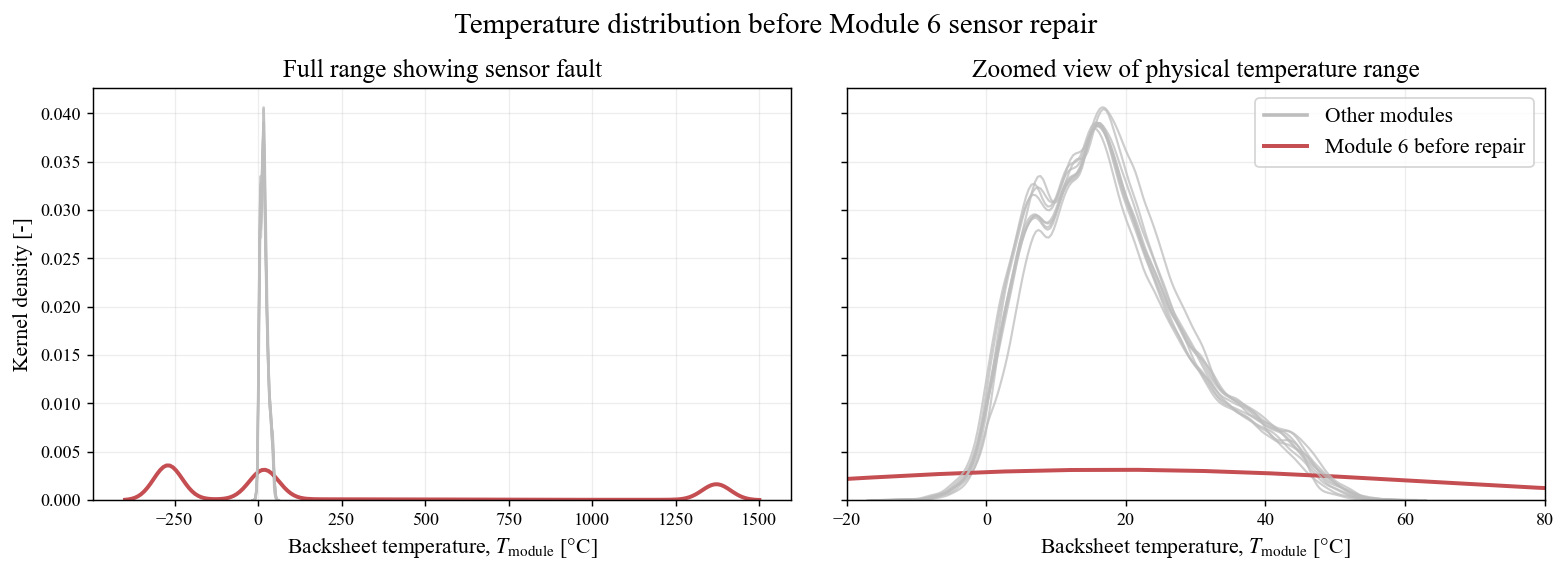

In [19]:
def plot_temperature_distribution_before_repair(
    df_input,
    save_name="fig04_07_temperature_distribution_before_module6_repair.png",
):
    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(12.2, 4.6),
        sharey=True,
    )

    modules = sorted(df_input["Module_ID"].unique())

    for module_id in modules:
        sub = df_input.loc[df_input["Module_ID"] == module_id, "Temp_Original"].dropna()

        if module_id == TARGET_TEMP_REPAIR_MODULE:
            sns.kdeplot(
                sub,
                ax=axes[0],
                color=RED,
                linewidth=2.2,
                bw_adjust=1.0,
            )
        else:
            sns.kdeplot(
                sub,
                ax=axes[0],
                color=GREY,
                alpha=0.75,
                linewidth=1.2,
                bw_adjust=1.0,
            )

    axes[0].set_title(
        "Full range showing sensor fault",
        fontsize=SUBTITLE_SIZE,
        pad=6,
    )
    axes[0].set_xlabel(
        r"Backsheet temperature, $T_\mathrm{module}$ [°C]",
        fontsize=AXIS_LABEL_SIZE,
    )
    axes[0].set_ylabel("Kernel density [-]", fontsize=AXIS_LABEL_SIZE)

    for module_id in modules:
        sub = df_input.loc[df_input["Module_ID"] == module_id, "Temp_Original"].dropna()

        if module_id == TARGET_TEMP_REPAIR_MODULE:
            sns.kdeplot(
                sub,
                ax=axes[1],
                color=RED,
                linewidth=2.2,
                bw_adjust=1.0,
            )
        else:
            sns.kdeplot(
                sub,
                ax=axes[1],
                color=GREY,
                alpha=0.75,
                linewidth=1.2,
                bw_adjust=1.0,
            )

    axes[1].set_xlim(-20, 80)
    axes[1].set_title(
        "Zoomed view of physical temperature range",
        fontsize=SUBTITLE_SIZE,
        pad=6,
    )
    axes[1].set_xlabel(
        r"Backsheet temperature, $T_\mathrm{module}$ [°C]",
        fontsize=AXIS_LABEL_SIZE,
    )
    axes[1].set_ylabel("")

    legend_items = [
        Line2D([0], [0], color=GREY, lw=2, label="Other modules"),
        Line2D([0], [0], color=RED, lw=2.2, label="Module 6 before repair"),
    ]

    axes[1].legend(
        handles=legend_items,
        loc="upper right",
        frameon=True,
        fontsize=LEGEND_SIZE,
    )

    fig.suptitle(
        "Temperature distribution before Module 6 sensor repair",
        fontsize=TITLE_SIZE,
        y=0.985,
    )

    fig.subplots_adjust(
        left=0.07,
        right=0.985,
        top=0.86,
        bottom=0.17,
        wspace=0.08,
    )

    save_fig(save_name, fig)
    plt.show()


plot_temperature_distribution_before_repair(df)

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\fig04_08_temperature_distribution_after_module6_repair.png


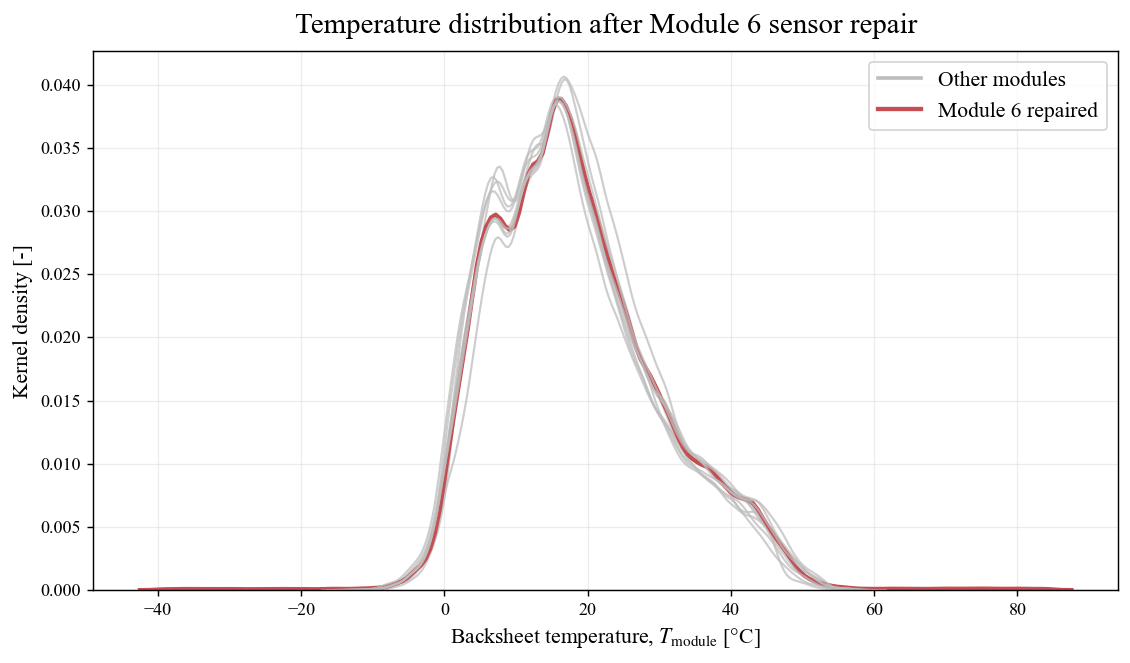

In [20]:
def plot_temperature_distribution_after_repair(
    df_input,
    save_name="fig04_08_temperature_distribution_after_module6_repair.png",
):
    fig, ax = plt.subplots(figsize=(8.8, 5.2))

    modules = sorted(df_input["Module_ID"].unique())

    for module_id in modules:
        sub = df_input.loc[df_input["Module_ID"] == module_id, "Temp"].dropna()

        if module_id == TARGET_TEMP_REPAIR_MODULE:
            sns.kdeplot(
                sub,
                ax=ax,
                color=RED,
                linewidth=2.4,
                bw_adjust=1.0,
            )
        else:
            sns.kdeplot(
                sub,
                ax=ax,
                color=GREY,
                alpha=0.75,
                linewidth=1.2,
                bw_adjust=1.0,
            )

    ax.set_title(
        "Temperature distribution after Module 6 sensor repair",
        fontsize=TITLE_SIZE,
        pad=10,
    )
    ax.set_xlabel(
        r"Backsheet temperature, $T_\mathrm{module}$ [°C]",
        fontsize=AXIS_LABEL_SIZE,
    )
    ax.set_ylabel("Kernel density [-]", fontsize=AXIS_LABEL_SIZE)

    legend_items = [
        Line2D([0], [0], color=GREY, lw=2, label="Other modules"),
        Line2D([0], [0], color=RED, lw=2.4, label="Module 6 repaired"),
    ]

    ax.legend(
        handles=legend_items,
        loc="upper right",
        frameon=True,
        fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()
    save_fig(save_name, fig)
    plt.show()


plot_temperature_distribution_after_repair(df)

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_temperature_boxplot_after_repair_by_module.png


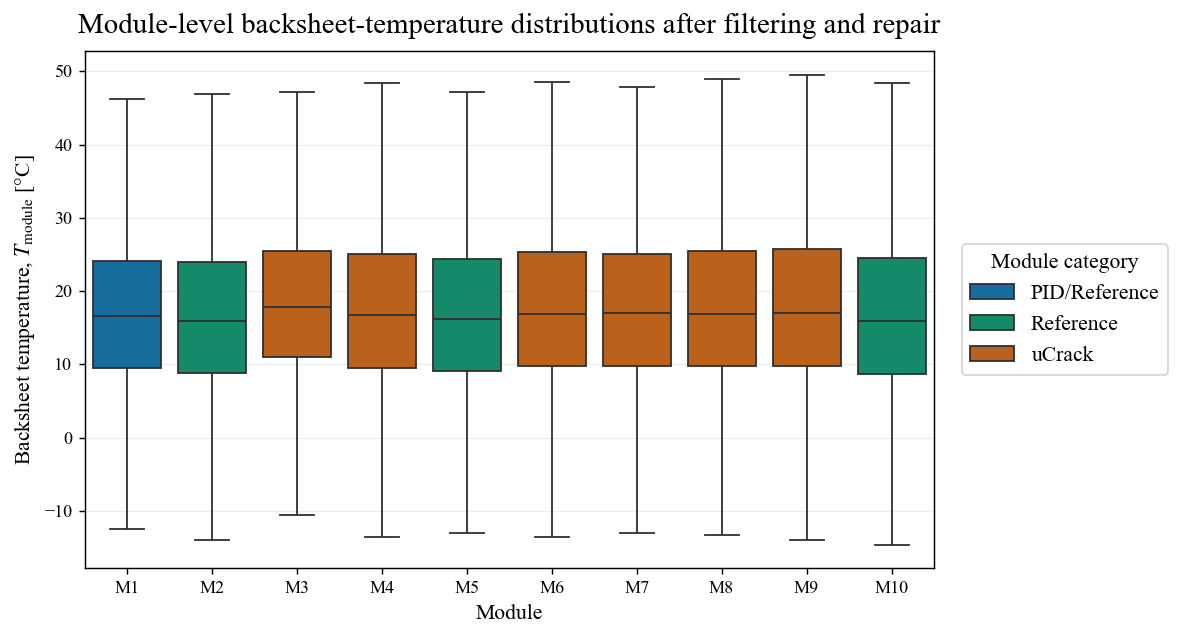

In [21]:
def plot_temperature_boxplot_after_repair(
    df_input,
    save_name="appendix_temperature_boxplot_after_repair_by_module.png",
):
    plot_df = df_input[["Module_ID", "Temp"]].copy()
    plot_df = plot_df.merge(module_meta[["Module_ID", "Type"]], on="Module_ID", how="left")
    plot_df["Module"] = "M" + plot_df["Module_ID"].astype(str)

    fig, ax = plt.subplots(figsize=(9.2, 5.0))

    sns.boxplot(
        data=plot_df,
        x="Module",
        y="Temp",
        hue="Type",
        palette=TYPE_COLORS,
        dodge=False,
        showfliers=False,
        ax=ax,
    )

    ax.set_title(
        "Module-level backsheet-temperature distributions after filtering and repair",
        fontsize=TITLE_SIZE,
        pad=10,
    )
    ax.set_xlabel("Module", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel(
        r"Backsheet temperature, $T_\mathrm{module}$ [°C]",
        fontsize=AXIS_LABEL_SIZE,
    )

    ax.legend(
        title="Module category",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()
    save_fig(save_name, fig)
    plt.show()


plot_temperature_boxplot_after_repair(df)

## 12. Save repaired dataset and summary tables

The repaired physical plausibility dataset is saved for downstream irradiance filtering and performance-metric calculation. Only the traceability columns needed to document the temperature repair are retained.

In [22]:
filter_summary_final = pd.DataFrame(filter_summary_rows)

display(filter_summary_final)

filter_summary_final.to_csv(
    FINAL_TABLE_DIR / "physical_filtering_and_temperature_repair_summary.csv",
    index=False,
)

,Step,Variable,Rule,Initial records,Retained records,Excluded records,Excluded [%]
0,Analysis window selection,Datetime_Local,2017-01-01 ≤ Datetime_Local < 2022-01-01,9130878,5522561,3608317,39.51774
1,Physical plausibility filtering,POA_GLOBAL,POA_GLOBAL ≥ 0 W/m² and POA_GLOBAL ≤ 1200 W/m²,5522561,5519872,2689,0.04869
2,Physical plausibility filtering,MPP,MPP ≥ 0 W and MPP ≤ 220 W,5519872,5519872,0,0.00000
3,Physical plausibility filtering,VMP,VMP ≥ 0 V and VMP ≤ 25 V,5519872,5519872,0,0.00000
4,Physical plausibility filtering,IMP,IMP ≥ 0 A and IMP ≤ 12 A,5519872,5519872,0,0.00000
5,Physical plausibility filtering,VOC,VOC ≥ 0 V and VOC ≤ 30 V,5519872,5519872,0,0.00000
6,Physical plausibility filtering,ISC,ISC ≥ 0 A and ISC ≤ 12 A,5519872,5519872,0,0.00000
7,Temperature validity after repair,Temp,-40°C ≤ T_module ≤ 85°C after Module 6 repair,5519872,5519872,0,0.00000


In [23]:
temperature_summary_after_repair = (
    df.merge(module_meta[["Module_ID", "Type"]], on="Module_ID", how="left")
    .groupby(["Module_ID", "Type"], as_index=False)
    .agg(
        n_records=("Temp", "size"),
        n_replaced=("Temp_Replaced", "sum"),
        temp_mean=("Temp", "mean"),
        temp_median=("Temp", "median"),
        temp_std=("Temp", "std"),
        temp_min=("Temp", "min"),
        temp_max=("Temp", "max"),
    )
)

display(temperature_summary_after_repair)

temperature_summary_after_repair.to_csv(
    FINAL_TABLE_DIR / "temperature_summary_after_repair_by_module.csv",
    index=False,
)

,Module_ID,Type,n_records,n_replaced,temp_mean,temp_median,temp_std,temp_min,temp_max
0,1,PID/Reference,587771,0,17.745286,16.657973,10.761392,-12.530754,57.684054
1,2,Reference,589735,0,17.352654,15.968675,11.262273,-14.155260,58.651989
2,3,uCrack,453966,0,18.878714,17.869607,10.671711,-13.272997,54.969829
3,4,uCrack,547586,0,18.196457,16.765584,11.492507,-13.908056,60.542064
4,5,Reference,587956,0,17.755542,16.271058,11.354129,-12.976609,59.035157
5,6,uCrack,550353,357602,18.401613,16.945292,11.904523,-39.983795,84.993921
6,7,uCrack,534549,0,18.228703,16.954302,11.259243,-13.923858,57.745610
7,8,uCrack,539899,0,18.431088,16.910281,11.602705,-13.296842,58.093902
8,9,uCrack,545193,0,18.630228,16.993393,11.746519,-13.910171,59.051504
9,10,Reference,582864,0,17.561219,15.946825,11.724563,-14.571776,59.147014


In [24]:
repair_source_summary = (
    df.loc[df["Temp_Replaced"]]
    .groupby(["Module_ID", "Temp_Repair_Source"], as_index=False)
    .agg(n_records=("Temp_Replaced", "size"))
)

display(repair_source_summary)

repair_source_summary.to_csv(
    FINAL_TABLE_DIR / "module6_temperature_repair_source_summary.csv",
    index=False,
)

,Module_ID,Temp_Repair_Source,n_records
0,6,same_15min_bin_other_modules_median,357600
1,6,same_date_other_modules_median,2


In [25]:
temporary_proxy_columns = [
    "Temp_Proxy_SameBin",
    "Temp_Proxy_DayHour",
    "Temp_Proxy_Day",
]

df = df.drop(
    columns=[col for col in temporary_proxy_columns if col in df.columns],
    errors="ignore",
)

df = df.sort_values(["Module_ID", "Datetime_Local"]).reset_index(drop=True)

df.to_parquet(REPAIRED_OUTPUT_PATH, index=False)

print("Saved repaired physical plausibility dataset:")
print(REPAIRED_OUTPUT_PATH)
print("Final shape:", df.shape)
print("Rows with replaced Module 6 temperature:", int(df["Temp_Replaced"].sum()))

Saved repaired physical plausibility dataset:
C:\Users\amina\Thesis\Final Pipeline\data_intermediate\df_plr_repaired.parquet
Final shape: (5519872, 27)
Rows with replaced Module 6 temperature: 357602
